In [ ]:
# If GPU needed for DNN/LSTM: Runtime > Change runtime type > GPU
!pip -q install pandas numpy scikit-learn xgboost lightgbm shap geopy tqdm plotly kaleido tensorflow==2.* ipywidgets

import os, sys, json, math, random, gc, time, pathlib, itertools, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb
import lightgbm as lgb
import shap

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from geopy.distance import geodesic
from datetime import datetime


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.3/66.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 47.9 MB/s eta 0:00:00


In [ ]:
# Project structure inside Colab/Drive (kept small; Git-friendly)
PROJECT = "taxi-fare-project"
BASE = pathlib.Path("/content") / PROJECT
DATA = BASE / "data"
RAW = DATA / "raw"
CLEAN = DATA / "clean"
PROC = DATA / "processed"
RESULTS = BASE / "results"
FIGS = RESULTS / "figures"
REPORT = BASE / "report"

for p in [BASE, DATA, RAW, CLEAN, PROC, RESULTS, FIGS, REPORT]:
    p.mkdir(parents=True, exist_ok=True)

# Team meta (goes to Members.txt later)
TEAM = {
    "leader": "Your Name",      # ⬅️ TODO
    "members": [
        {"name": "Member A", "role": "Data cleaning & ingestion"},
        {"name": "Member B", "role": "Feature engineering & EDA"},
        {"name": "Member C", "role": "Modeling (LR/MLP/RF/XGB)"},
        {"name": "Member D", "role": "Advanced (DNN/LSTM)"}
    ],
    "course": "SE4050 Deep Learning - July 2025",
    "dataset": "Kaggle NYC Taxi Fare Prediction",
}
TEAM


{'leader': 'Your Name',
 'members': [{'name': 'Member A', 'role': 'Data cleaning & ingestion'},
  {'name': 'Member B', 'role': 'Feature engineering & EDA'},
  {'name': 'Member C', 'role': 'Modeling (LR/MLP/RF/XGB)'},
  {'name': 'Member D', 'role': 'Advanced (DNN/LSTM)'}],
 'course': 'SE4050 Deep Learning - July 2025',
 'dataset': 'Kaggle NYC Taxi Fare Prediction'}

In [ ]:
# Make project folders (adjust names if you changed them)
import pathlib, os
PROJECT = "taxi-fare-project"
BASE = pathlib.Path("/content") / PROJECT
RAW = BASE / "data" / "raw"
RAW.mkdir(parents=True, exist_ok=True)

# Move kaggle.json into the right place with correct permissions
KAGGLE_USER_JSON = "/content/kaggle.json"
assert os.path.exists(KAGGLE_USER_JSON), "Upload kaggle.json first (left sidebar > Files > Upload)"

!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle API configured.")


Kaggle API configured.


In [ ]:
# Download & unzip into data/raw
!kaggle competitions download -c new-york-city-taxi-fare-prediction -p $RAW --force
!unzip -o $RAW/new-york-city-taxi-fare-prediction.zip -d $RAW

# Quick check
!ls -lh $RAW


 99% 1.55G/1.56G [00:18<00:00, 269MB/s]
100% 1.56G/1.56G [00:18<00:00, 90.8MB/s]
Archive:  /content/taxi-fare-project/data/raw/new-york-city-taxi-fare-prediction.zip
  inflating: /content/taxi-fare-project/data/raw/GCP-Coupons-Instructions.rtf  
  inflating: /content/taxi-fare-project/data/raw/sample_submission.csv  
  inflating: /content/taxi-fare-project/data/raw/test.csv  
  inflating: /content/taxi-fare-project/data/raw/train.csv  
total 6.9G
-rw-r--r-- 1 root root  486 Dec 12  2019 GCP-Coupons-Instructions.rtf
-rw-r--r-- 1 root root 1.6G Dec 12  2019 new-york-city-taxi-fare-prediction.zip
-rw-r--r-- 1 root root 336K Dec 12  2019 sample_submission.csv
-rw-r--r-- 1 root root 960K Dec 12  2019 test.csv
-rw-r--r-- 1 root root 5.4G Dec 12  2019 train.csv


In [ ]:
import pandas as pd

train_path = RAW / "train.csv"
assert train_path.exists(), f"train.csv not found at {train_path}"

usecols = ["pickup_datetime","pickup_longitude","pickup_latitude",
           "dropoff_longitude","dropoff_latitude","passenger_count","fare_amount"]

df = pd.read_csv(train_path, usecols=usecols, nrows=1_000_000)  # sample 1M rows for speed
print(df.shape)
df.head()


(1000000, 7)


,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1
1,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1
2,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2
3,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1
4,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1


In [ ]:
# NYC bounding box to filter outliers
NYC_LAT_MIN, NYC_LAT_MAX = 40.4774, 40.9176
NYC_LON_MIN, NYC_LON_MAX = -74.2591, -73.7004

def valid_coord(lat, lon):
    return (NYC_LAT_MIN <= lat <= NYC_LAT_MAX) and (NYC_LON_MIN <= lon <= NYC_LON_MAX)

# Parse datetime
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"], errors="coerce", utc=True)
df = df.dropna(subset=["pickup_datetime"])

# Basic cleaning rules
df = df[(df["fare_amount"] > 0) & (df["fare_amount"] <= 500)]
df = df[(df["passenger_count"] > 0) & (df["passenger_count"] <= 8)]

# Remove coords outside NYC
mask_pick = df.apply(lambda r: valid_coord(r["pickup_latitude"], r["pickup_longitude"]), axis=1)
mask_drop = df.apply(lambda r: valid_coord(r["dropoff_latitude"], r["dropoff_longitude"]), axis=1)
df = df[mask_pick & mask_drop].copy()

# Haversine distance (vectorized)
def haversine_vectorized(lat1, lon1, lat2, lon2):
    # Earth radius in km
    R = 6371.0088
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    c = 2*np.arcsin(np.sqrt(a))
    return R*c

df["distance_km"] = haversine_vectorized(
    df["pickup_latitude"].values,
    df["pickup_longitude"].values,
    df["dropoff_latitude"].values,
    df["dropoff_longitude"].values,
)

# Drop zero distance or extreme trips
df = df[(df["distance_km"] > 0) & (df["distance_km"] <= 200)].copy()

# Time features
dt = df["pickup_datetime"].dt
df["hour"] = dt.hour
df["dayofweek"] = dt.dayofweek  # Monday=0
df["month"] = dt.month
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
df["is_peak"] = ((df["hour"].between(7,9)) | (df["hour"].between(16,19))).astype(int)

# Cyclical encodings
df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)
df["dow_sin"] = np.sin(2*np.pi*df["dayofweek"]/7)
df["dow_cos"] = np.cos(2*np.pi*df["dayofweek"]/7)

# Save cleaned
clean_path = CLEAN / "taxi_clean.csv"
df.to_csv(clean_path, index=False)
clean_path, df.shape


(PosixPath('/content/taxi-fare-project/data/clean/taxi_clean.csv'),
 (964183, 17))

In [ ]:
from sklearn.cluster import MiniBatchKMeans

N_CLUSTERS = 100  # try 50–200

coords_pick = df[["pickup_latitude","pickup_longitude"]].values
coords_drop = df[["dropoff_latitude","dropoff_longitude"]].values

kmeans_pick = MiniBatchKMeans(n_clusters=N_CLUSTERS, batch_size=10_000, random_state=42)
kmeans_drop = MiniBatchKMeans(n_clusters=N_CLUSTERS, batch_size=10_000, random_state=42)

df["pickup_zone"] = kmeans_pick.fit_predict(coords_pick)
df["dropoff_zone"] = kmeans_drop.fit_predict(coords_drop)

proc_path = PROC / "taxi_features.csv"
df.to_csv(proc_path, index=False)
proc_path, df.shape, df[["pickup_zone","dropoff_zone"]].nunique()


(PosixPath('/content/taxi-fare-project/data/processed/taxi_features.csv'),
 (964183, 19),
 pickup_zone     100
 dropoff_zone    100
 dtype: int64)

In [ ]:
!pip install -q kaleido



In [ ]:
import plotly.express as px

In [ ]:
!pip install -q --no-cache-dir kaleido


In [ ]:
import kaleido
print("Kaleido installed successfully ✅")


Kaleido installed successfully ✅


In [ ]:
import plotly.express as px

# Fare distribution
fig = px.histogram(df.sample(min(len(df), 200_000)), x="fare_amount", nbins=100, title="Fare Distribution (USD)")
#fig.write_image(str(FIGS / "fare_distribution.png"))
fig.show()

# Distance vs Fare scatter (sample)
sample = df.sample(min(len(df), 100_000), random_state=42)
fig = px.scatter(sample, x="distance_km", y="fare_amount", opacity=0.3, title="Distance vs Fare")
#fig.write_image(str(FIGS / "distance_vs_fare.png"))
fig.show()

# Average fare by hour
hourly = df.groupby("hour")["fare_amount"].mean().reset_index()
fig = px.bar(hourly, x="hour", y="fare_amount", title="Average Fare by Hour")
#fig.write_image(str(FIGS / "avg_fare_by_hour.png"))
fig.show()


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Feature set (trip-level)
feature_cols = [
    "pickup_longitude","pickup_latitude","dropoff_longitude","dropoff_latitude",
    "passenger_count","distance_km",
    "hour","dayofweek","month","is_weekend","is_peak",
    "hour_sin","hour_cos","dow_sin","dow_cos",
    "pickup_zone","dropoff_zone"
]
target_col = "fare_amount"

X = df[feature_cols].copy()
y = df[target_col].values

# One-hot small-cardinality vs leave zones numeric for tree models (OK). For DNN/MLP, scaling helps.
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test   = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

X_train.shape, X_val.shape, X_test.shape


((674928, 17), (144627, 17), (144628, 17))

In [ ]:
def evaluate_and_log(name, y_true, y_pred, out_csv=RESULTS/"model_metrics.csv"):
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    medae = np.median(np.abs(y_true - y_pred))
    row = pd.DataFrame([{"model":name, "rmse":rmse, "mae":mae, "r2":r2, "median_ae":medae}])
    if out_csv.exists():
        row.to_csv(out_csv, mode="a", header=False, index=False)
    else:
        row.to_csv(out_csv, index=False)
    return row

def print_metrics_table(csv_path=RESULTS/"model_metrics.csv"):
    dfm = pd.read_csv(csv_path)
    display(dfm.sort_values("rmse"))


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_and_log(name, y_true, y_pred, out_csv=RESULTS/"model_metrics.csv"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))   # <-- no squared=False
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    medae = np.median(np.abs(y_true - y_pred))
    row = pd.DataFrame([{"model":name, "rmse":rmse, "mae":mae, "r2":r2, "median_ae":medae}])
    if out_csv.exists():
        row.to_csv(out_csv, mode="a", header=False, index=False)
    else:
        row.to_csv(out_csv, index=False)
    return row


In [ ]:
# Numeric scaling for LR/MLP/DNN
num_cols = feature_cols
preprocess = ColumnTransformer(
    transformers=[("num", StandardScaler(), num_cols)],
    remainder="drop"
)

# Linear Regression
lr = Pipeline(steps=[("prep", preprocess), ("model", LinearRegression())])
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_val)
evaluate_and_log("LinearRegression", y_val, pred_lr)

# MLP baseline
mlp = Pipeline(steps=[
    ("prep", preprocess),
    ("model", MLPRegressor(hidden_layer_sizes=(64,32), activation="relu",
                           alpha=1e-4, learning_rate_init=1e-3,
                           batch_size=1024, max_iter=30, random_state=42,
                           early_stopping=True, n_iter_no_change=5))
])
mlp.fit(X_train, y_train)
pred_mlp = mlp.predict(X_val)
evaluate_and_log("MLP(baseline)", y_val, pred_mlp)

print_metrics_table()


,model,rmse,mae,r2,median_ae
1,MLP(baseline),3.989754,1.957632,0.822507,1.209569
0,LinearRegression,4.546686,2.274754,0.769496,1.415748


In [ ]:
# Random Forest (no scaling needed)
rf = RandomForestRegressor(
    n_estimators=200, max_depth=None, min_samples_leaf=5, n_jobs=-1, random_state=42
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_val)
evaluate_and_log("RandomForest", y_val, pred_rf)

# XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    tree_method="hist", eval_metric="rmse"
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)
pred_xgb = xgb_model.predict(X_val)
evaluate_and_log("XGBoost", y_val, pred_xgb)

print_metrics_table()


,model,rmse,mae,r2,median_ae
2,RandomForest,3.853594,1.893060,0.834415,1.143981
3,XGBoost,3.854341,1.918716,0.834351,1.171077
1,MLP(baseline),3.989754,1.957632,0.822507,1.209569
0,LinearRegression,4.546686,2.274754,0.769496,1.415748


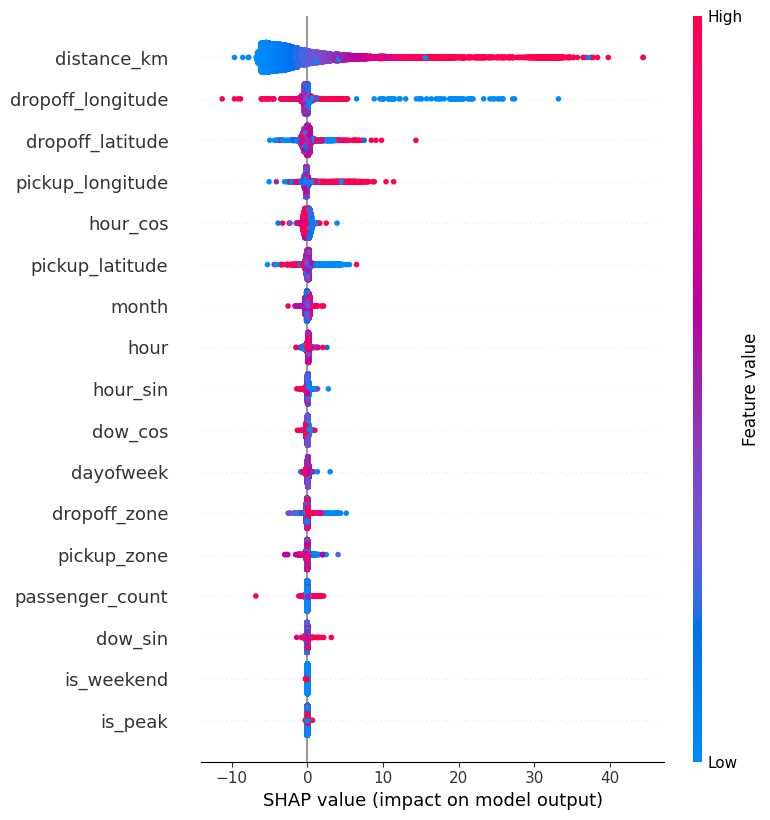

In [32]:
# Gain importance
imp = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)
imp.head(15)

# SHAP summary (sample for speed)
shap.initjs()
explainer = shap.TreeExplainer(xgb_model)
X_val_sample = X_val.sample(20000, random_state=42)
shap_values = explainer.shap_values(X_val_sample)
shap.summary_plot(shap_values, X_val_sample, show=False)
plt.tight_layout()
plt.savefig(FIGS / "shap_summary_xgb.png", dpi=150, bbox_inches="tight")
plt.show()


In [33]:
# Build Keras DNN on scaled features
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(X_train)
Xv_s  = scaler.transform(X_val)
Xte_s = scaler.transform(X_test)

dnn = keras.Sequential([
    layers.Input(shape=(Xtr_s.shape[1],)),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dense(1)
])
dnn.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=[keras.metrics.RootMeanSquaredError()])

es = keras.callbacks.EarlyStopping(monitor="val_root_mean_squared_error", patience=5, restore_best_weights=True)
hist = dnn.fit(Xtr_s, y_train, validation_data=(Xv_s, y_val), epochs=50, batch_size=2048, callbacks=[es], verbose=0)

pred_dnn = dnn.predict(Xv_s).ravel()
evaluate_and_log("DNN(tabular)", y_val, pred_dnn)

print_metrics_table()


4520/4520 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


,model,rmse,mae,r2,median_ae
2,RandomForest,3.853594,1.893060,0.834415,1.143981
3,XGBoost,3.854341,1.918716,0.834351,1.171077
1,MLP(baseline),3.989754,1.957632,0.822507,1.209569
4,DNN(tabular),4.126826,2.000746,0.810102,1.200941
0,LinearRegression,4.546686,2.274754,0.769496,1.415748


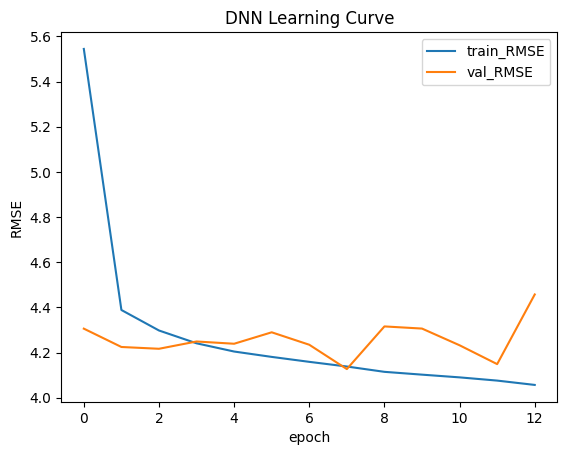

In [34]:
plt.figure()
plt.plot(hist.history["root_mean_squared_error"], label="train_RMSE")
plt.plot(hist.history["val_root_mean_squared_error"], label="val_RMSE")
plt.legend(); plt.title("DNN Learning Curve"); plt.xlabel("epoch"); plt.ylabel("RMSE")
plt.savefig(FIGS / "dnn_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()


In [35]:
# Aggregate to hourly series
df_hourly = (df
    .set_index("pickup_datetime")
    .resample("1H")
    .agg(avg_fare=("fare_amount","mean"),
         trip_count=("fare_amount","size"),
         avg_distance=("distance_km","mean"),
         avg_pass=("passenger_count","mean"))
    .dropna()
)
df_hourly.head()

# Fill small gaps if any
df_hourly = df_hourly.fillna(method="ffill")

# Build sequences of length k -> predict next-step avg_fare
k = 24
features_seq = ["avg_fare","trip_count","avg_distance","avg_pass"]
data_seq = df_hourly[features_seq].values

# Normalize
seq_scaler = StandardScaler()
data_scaled = seq_scaler.fit_transform(data_seq)

def make_sequences(data, k):
    Xs, ys = [], []
    for i in range(k, len(data)):
        Xs.append(data[i-k:i, :])
        ys.append(data[i, 0])  # next-step avg_fare
    return np.array(Xs), np.array(ys)

X_seq, y_seq = make_sequences(data_scaled, k)
split = int(0.8 * len(X_seq))
Xtr_seq, Xv_seq = X_seq[:split], X_seq[split:]
ytr_seq, yv_seq = y_seq[:split], y_seq[split:]

# LSTM model
lstm = keras.Sequential([
    layers.Input(shape=(k, len(features_seq))),
    layers.LSTM(128, dropout=0.2, recurrent_dropout=0.1, return_sequences=False),
    layers.Dense(64, activation="relu"),
    layers.Dense(1)
])
lstm.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=[keras.metrics.RootMeanSquaredError()])

es2 = keras.callbacks.EarlyStopping(monitor="val_root_mean_squared_error", patience=5, restore_best_weights=True)
hist2 = lstm.fit(Xtr_seq, ytr_seq, validation_data=(Xv_seq, yv_seq),
                 epochs=50, batch_size=256, verbose=0, callbacks=[es2])

pred_seq_val = lstm.predict(Xv_seq).ravel()
# Unscale RMSE to fare units:
# Our target was the first column avg_fare, so transform back:
yv_seq_unscaled = seq_scaler.inverse_transform(
    np.column_stack([yv_seq, np.zeros((len(yv_seq), len(features_seq)-1))])
)[:,0]
pred_seq_unscaled = seq_scaler.inverse_transform(
    np.column_stack([pred_seq_val, np.zeros((len(pred_seq_val), len(features_seq)-1))])
)[:,0]

row = evaluate_and_log("LSTM(hourly_avg_fare)", yv_seq_unscaled, pred_seq_unscaled)
row, print_metrics_table()


354/354 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step


,model,rmse,mae,r2,median_ae
2,RandomForest,3.853594,1.893060,0.834415,1.143981
3,XGBoost,3.854341,1.918716,0.834351,1.171077
1,MLP(baseline),3.989754,1.957632,0.822507,1.209569
4,DNN(tabular),4.126826,2.000746,0.810102,1.200941
5,LSTM(hourly_avg_fare),4.298920,2.877077,0.056012,2.061069
0,LinearRegression,4.546686,2.274754,0.769496,1.415748


(                   model     rmse       mae        r2  median_ae
 0  LSTM(hourly_avg_fare)  4.29892  2.877077  0.056012   2.061069,
 None)

          model      rmse       mae        r2  median_ae
0  XGBoost-TEST  3.729645  1.898431  0.842059   1.175382


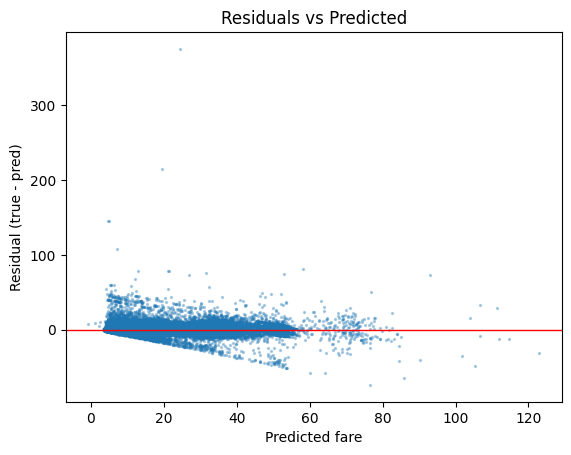

In [40]:
# Pick your best model (example: xgb_model or dnn)
best_model_name = "XGBoost"  # ⬅️ set after you compare val metrics
if best_model_name == "XGBoost":
    final_pred = xgb_model.predict(X_test)
elif best_model_name == "RandomForest":
    final_pred = rf.predict(X_test)
elif best_model_name == "DNN(tabular)":
    final_pred = dnn.predict(scaler.transform(X_test)).ravel()
else:
    final_pred = mlp.predict(X_test)

final_metrics = evaluate_and_log(best_model_name+"-TEST", y_test, final_pred, out_csv=RESULTS/"model_metrics.csv")
print(final_metrics)

# Residual plots
resid = y_test - final_pred
plt.figure()
plt.scatter(final_pred, resid, s=2, alpha=0.3)
plt.axhline(0, color="red", lw=1)
plt.xlabel("Predicted fare"); plt.ylabel("Residual (true - pred)")
plt.title("Residuals vs Predicted")
plt.savefig(FIGS / "residuals_vs_pred.png", dpi=150, bbox_inches="tight")
plt.show()


In [39]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.metrics import mean_squared_error

# RMSE by distance buckets (robust)
bins = [0,1,2,5,10,20,50,200]
labels = ["0-1","1-2","2-5","5-10","10-20","20-50","50-200"]

dist_bucket = pd.cut(X_test["distance_km"], bins=bins, labels=labels, include_lowest=True)
bucket_df = pd.DataFrame({
    "bucket": dist_bucket,
    "y": y_test,
    "yhat": final_pred
}).dropna()

# Safely compute RMSE only for non-empty buckets
rmse_records = []
for b in labels:
    g = bucket_df[bucket_df["bucket"] == b]
    if len(g) > 0:
        rmse = np.sqrt(mean_squared_error(g["y"], g["yhat"]))
        rmse_records.append({"bucket": b, "rmse": rmse})
    else:
        rmse_records.append({"bucket": b, "rmse": np.nan})  # mark empty bins as NaN

rmse_by_bucket = pd.DataFrame(rmse_records)

display(rmse_by_bucket)

# Bar chart
fig = px.bar(rmse_by_bucket, x="bucket", y="rmse",
             title="RMSE by Distance Bucket",
             text_auto=".2f",
             color="rmse",
             color_continuous_scale="Blues")

fig.update_layout(yaxis_title="RMSE", xaxis_title="Distance Range (km)")
#fig.write_image(str(FIGS / "rmse_by_bucket.png"))
fig.show()


,bucket,rmse
0,0-1,5.369634
1,1-2,2.128600
2,2-5,2.716329
3,5-10,4.404404
4,10-20,7.136107
5,20-50,8.760892
6,50-200,NaN


In [41]:
# Save a compact inference demo function
import joblib
joblib.dump(rf, RESULTS/"rf_model.joblib")
joblib.dump(xgb_model, RESULTS/"xgb_model.joblib")
joblib.dump(mlp, RESULTS/"mlp_model.joblib")
joblib.dump(lr, RESULTS/"lr_model.joblib")
joblib.dump(scaler, RESULTS/"scaler.joblib")

# Demo: predict a sample trip
def predict_fare(sample_row: dict, model="xgb"):
    # sample_row keys must match feature_cols
    x = pd.DataFrame([sample_row])[feature_cols]
    if model=="xgb":
        return float(xgb_model.predict(x)[0])
    elif model=="rf":
        return float(rf.predict(x)[0])
    elif model=="dnn":
        return float(dnn.predict(scaler.transform(x)).ravel()[0])
    elif model=="mlp":
        return float(mlp.predict(x)[0])
    else:
        return float(lr.predict(x)[0])

# Example (Manhattan: a ~4km ride, 1 passenger, weekday 8am)
example = {
 "pickup_longitude": -73.9857, "pickup_latitude": 40.7484,
 "dropoff_longitude": -73.9772, "dropoff_latitude": 40.7527,
 "passenger_count": 1, "distance_km": 1.0,
 "hour": 8, "dayofweek": 2, "month": 10, "is_weekend": 0, "is_peak": 1,
 "hour_sin": np.sin(2*np.pi*8/24), "hour_cos": np.cos(2*np.pi*8/24),
 "dow_sin": np.sin(2*np.pi*2/7), "dow_cos": np.cos(2*np.pi*2/7),
 "pickup_zone": 0, "dropoff_zone": 0
}
print("Demo fare (XGB): $", round(predict_fare(example, "xgb"), 2))

# Export final metrics table
print_metrics_table()


Demo fare (XGB): $ 5.94


,model,rmse,mae,r2,median_ae
6,XGBoost-TEST,3.729645,1.898431,0.842059,1.175382
7,XGBoost-TEST,3.729645,1.898431,0.842059,1.175382
8,XGBoost-TEST,3.729645,1.898431,0.842059,1.175382
2,RandomForest,3.853594,1.893060,0.834415,1.143981
3,XGBoost,3.854341,1.918716,0.834351,1.171077
1,MLP(baseline),3.989754,1.957632,0.822507,1.209569
4,DNN(tabular),4.126826,2.000746,0.810102,1.200941
5,LSTM(hourly_avg_fare),4.298920,2.877077,0.056012,2.061069
0,LinearRegression,4.546686,2.274754,0.769496,1.415748
